In [18]:
!git clone https://github.com/serengil/deepface.

Cloning into 'deepface.'...
fatal: could not read Username for 'https://github.com': No such device or address


In [1]:
import os

# Change to the deepface directory
os.chdir('deepface')

# Install deepface from the cloned source in editable mode with tensorflow support
!pip install -e .[tensorflow]

# Change back to the original directory (optional, but good practice)
os.chdir('..')

Obtaining file:///content/deepface
  Preparing metadata (setup.py) ... done
  Attempting uninstall: deepface
    Found existing installation: deepface 0.0.102
    Uninstalling deepface-0.0.102:
      Successfully uninstalled deepface-0.0.102
  Running setup.py develop for deepface


In [4]:

result: dict = DeepFace.verify(img1_path = "img1.jpg", img2_path = "img2.jpg")

NameError: name 'DeepFace' is not defined

In [3]:
from deepface import DeepFace

# register images into the database
_ = DeepFace.register(img = "img1.jpg")
_ = DeepFace.register(img = ["img2.jpg", "img3.jpg"])

# identify a given image with a registered face
result: dict = DeepFace.identify(img = "target.jpg", identity_id = "17")

# perform exact search
dfs: List[pd.DataFrame] = DeepFace.search(img = "target.jpg")

# building index is required for ann search on postgres/mongo, but skipped for native vector dbs
_ = DeepFace.build_index()

# perform approximate nearest neighbor search
dfs: List[pd.DataFrame] = DeepFace.search(img = "target.jpg", search_method = "ann")

ImportError: cannot import name '__version__' from 'deepface' (unknown location)

### Capture Image from Webcam and Recognize Face

First, let's make sure DeepFace can be imported correctly. Then, we'll capture an image using your webcam, save it, and perform facial analysis.

In [10]:
import sys
import os

# Ensure the cloned deepface directory is in sys.path
deepface_path = os.path.abspath('deepface')
if deepface_path not in sys.path:
    sys.path.insert(0, deepface_path)

# Remove deepface and its submodules from sys.modules to force a clean reload
for module_name in list(sys.modules.keys()):
    if module_name.startswith('deepface'):
        del sys.modules[module_name]

# Now, try importing DeepFace directly
from deepface import DeepFace

print("DeepFace imported successfully!")

26-10-01 06:05:41 - ⚠️ 
 ⚠️ DEPRECATION WARNING:
 Running 'pip install deepface' alone will no longer be sufficient and will
 NOT install a default backend in an upcoming major release.

 Currently, TensorFlow is included by default, but this behavior will be deprecated.
 Please explicitly specify your preferred backend engine when installing:

   -> pip install deepface[tensorflow]
   -> pip install deepface[pytorch]

 Otherwise, you will encounter 'module not found' errors.

26-10-01 06:05:44 - Directory /root/.deepface has been created
26-10-01 06:05:44 - Directory /root/.deepface/weights has been created
DeepFace imported successfully!


Now, let's capture an image from your webcam. You will be prompted to allow camera access.

In [15]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Capture';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});

            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            // Resize the output to fit the video element.
            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getVideoTracks()[0].stop();
            div.remove();
            return canvas.toDataURL('image/jpeg', quality);
        }
        ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

try:
    image_file = take_photo()
    print(f'Saved image to {image_file}')
except Exception as err:
    # Errors will be thrown if the user does not have a webcam or does not allow access
    print(str(err))
    image_file = None # Set to None if capture failed


<IPython.core.display.Javascript object>

Saved image to photo.jpg


Now that we have captured an image, let's use DeepFace to analyze the face(s) in it. This will detect faces and infer attributes like age, gender, race, and emotion.

Action: emotion: 100%|██████████| 4/4 [00:01<00:00,  2.74it/s]


Analysis Results:
-----------------
Face Detected at: {'x': 291, 'y': 244, 'w': 168, 'h': 168, 'left_eye': None, 'right_eye': None}
Age: 23
Gender: {'Woman': np.float32(0.0005788976), 'Man': np.float32(99.99941)}
Race: black ({'asian': np.float32(3.506434), 'indian': np.float32(24.46466), 'black': np.float32(61.50225), 'white': np.float32(1.041624), 'middle eastern': np.float32(0.86630636), 'latino hispanic': np.float32(8.61872)})
Emotion: neutral ({'angry': np.float32(0.15490131), 'disgust': np.float32(1.1881355e-07), 'fear': np.float32(0.16957517), 'happy': np.float32(0.027244188), 'sad': np.float32(0.80326915), 'surprise': np.float32(0.0013830226), 'neutral': np.float32(98.84362)})
-----------------
Face Detected at: {'x': 45, 'y': 399, 'w': 67, 'h': 67, 'left_eye': None, 'right_eye': None}
Age: 31
Gender: {'Woman': np.float32(11.753748), 'Man': np.float32(88.24625)}
Race: white ({'asian': np.float32(0.41405195), 'indian': np.float32(0.055115625), 'black': np.float32(0.0018981715), 

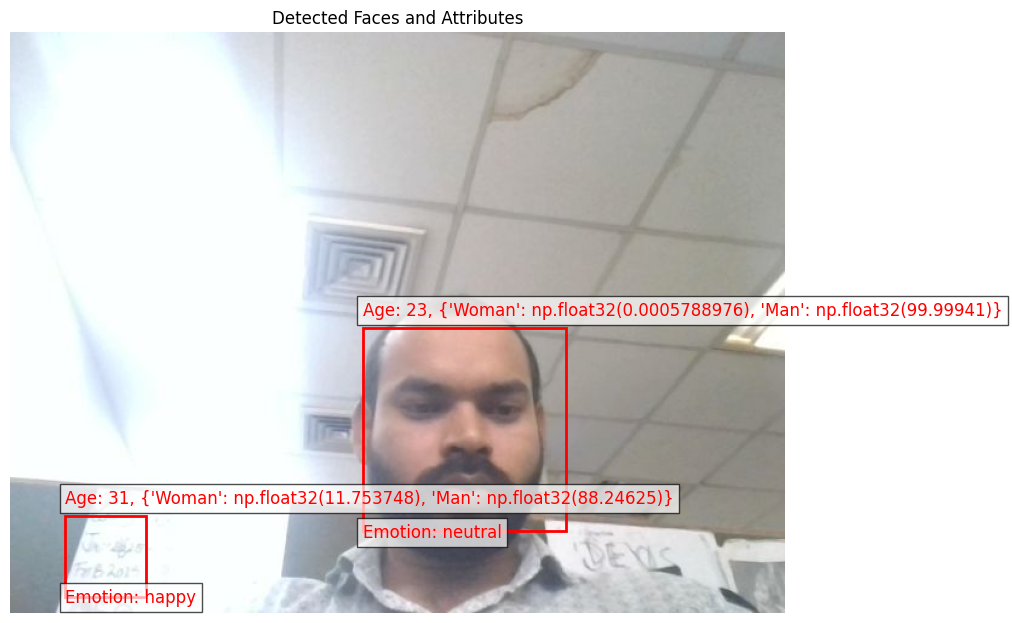

In [16]:
import matplotlib.pyplot as plt
import cv2

if image_file:
    try:
        # Analyze the captured image
        analysis_results = DeepFace.analyze(img_path=image_file, actions=['age', 'gender', 'race', 'emotion'])

        if analysis_results:
            print("Analysis Results:")
            for result in analysis_results:
                print("-----------------")
                print(f"Face Detected at: {result['region']}")
                print(f"Age: {result['age']}")
                print(f"Gender: {result['gender']}")
                print(f"Race: {result['dominant_race']} ({result['race']})")
                print(f"Emotion: {result['dominant_emotion']} ({result['emotion']})")

            # Optionally, display the image with detected faces
            img = cv2.imread(image_file)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.figure(figsize=(10, 8))
            plt.imshow(img)
            plt.axis('off')

            for result in analysis_results:
                x, y, w, h = result['region']['x'], result['region']['y'], result['region']['w'], result['region']['h']
                plt.gca().add_patch(plt.Rectangle((x, y), w, h, fill=False, edgecolor='red', linewidth=2))
                plt.text(x, y - 10, f"Age: {result['age']}, {result['gender']}", color='red', fontsize=12, bbox=dict(facecolor='white', alpha=0.7))
                plt.text(x, y + h + 5, f"Emotion: {result['dominant_emotion']}", color='red', fontsize=12, bbox=dict(facecolor='white', alpha=0.7))

            plt.title('Detected Faces and Attributes')
            plt.show()
        else:
            print("No faces detected in the image.")

    except Exception as e:
        print(f"Error during DeepFace analysis: {e}")
else:
    print("No image was captured, cannot perform face analysis.")

### Capture Another Image for Verification

Now, let's capture a second image to compare against the first one (`photo.jpg`).

In [17]:
try:
    # Capture a new image, saving it as 'photo2.jpg'
    image_file_2 = take_photo(filename='photo2.jpg')
    print(f'Saved second image to {image_file_2}')
except Exception as err:
    print(str(err))
    image_file_2 = None # Set to None if capture failed

<IPython.core.display.Javascript object>

Saved second image to photo2.jpg


### Verify if it's the Same Person

Now we will use `DeepFace.verify` to compare `photo.jpg` (the first image) with `photo2.jpg` (the newly captured image).

26-10-01 06:08:50 - 🔗 vgg_face_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5 to /root/.deepface/weights/vgg_face_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5
To: /root/.deepface/weights/vgg_face_weights.h5
100%|██████████| 580M/580M [00:01<00:00, 321MB/s]


Verification Result:
{'verified': True, 'distance': 0.143354, 'threshold': 0.68, 'confidence': 100, 'model': 'VGG-Face', 'detector_backend': 'opencv', 'similarity_metric': 'cosine', 'facial_areas': {'img1': {'x': 302, 'y': 91, 'w': 191, 'h': 191, 'left_eye': (437, 170), 'right_eye': (357, 163)}, 'img2': {'x': 324, 'y': 210, 'w': 195, 'h': 195, 'left_eye': (459, 291), 'right_eye': (381, 284)}}, 'time': 5.46}
The two images belong to the same person.


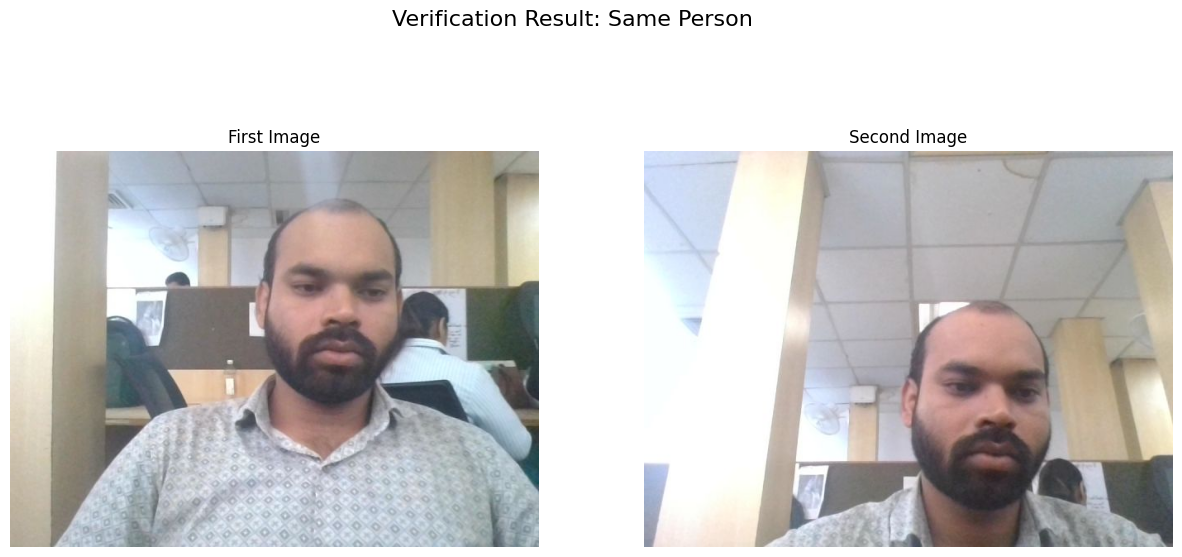

In [14]:
if image_file and image_file_2:
    try:
        verification_result = DeepFace.verify(img1_path=image_file, img2_path=image_file_2)

        print("Verification Result:")
        print(verification_result)

        if verification_result['verified']:
            print("The two images belong to the same person.")
        else:
            print("The two images belong to different persons.")

        # Display both images side-by-side for visual confirmation
        img1 = cv2.imread(image_file)
        img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

        img2 = cv2.imread(image_file_2)
        img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(15, 7))

        plt.subplot(1, 2, 1)
        plt.imshow(img1)
        plt.title('First Image')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(img2)
        plt.title('Second Image')
        plt.axis('off')

        plt.suptitle(f"Verification Result: {'Same Person' if verification_result['verified'] else 'Different Persons'}", fontsize=16)
        plt.show()

    except Exception as e:
        print(f"Error during DeepFace verification: {e}")
else:
    print("Could not perform verification because one or both images were not captured.")